
# 01 — SEALS Bead Comparison and Size Sweep

**SIMULATED / SYNTHETIC** (Mie-theory forward model, not new laboratory measurement) —
reproducing [`SEALS_paper.pdf`](../../../../Spring2026/MATLAB/SEALS/original%20files/SEALS_paper.pdf)
Fig. 5's 7.32 &micro;m / 9.94 &micro;m polystyrene bead comparison, then extending to a
diameter sweep. Every function called here is already tested
(`tests/test_bead_features.py`, `tests/test_seals_inverse_measurement.py`) and reuses this
repo's existing, validated Mie/SEALS physics (`inverse/_seals_physics.py`,
`inverse/measurement.py`) rather than reimplementing it.

**Physical parameters confirmed directly against the paper** (read 2026-08-16): refractive
index **n = 1.39** (the paper's own citation [15]) and the **20 nm bandwidth centered at
1590 nm** both match this repo's existing defaults exactly — these are not placeholder
values.


In [1]:

import sys, pathlib
sys.path.insert(0, str(pathlib.Path('.').resolve().parents[2]))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
sp.init_printing()

from projects.seals.morphology_classification.bead_features import (
    compute_bead_trace, extract_features, PAPER_BEAD_SMALL_M, PAPER_BEAD_LARGE_M,
)
from projects.seals.inverse import _seals_physics as physics

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print(f"refractive index n = {physics.P_DEFAULT['npar']} (paper citation [15])")
print(f"wavelength range: {physics.P_DEFAULT['lam1']*1e9:.0f}-{physics.P_DEFAULT['lam2']*1e9:.0f} nm")


refractive index n = 1.39 (paper citation [15])
wavelength range: 1580-1600 nm



## PART 1 — Reproduce the bead comparison

### QUESTION
Does the SEALS Mie-scattering simulation, run at the paper's own stated parameters,
reproduce the paper's own stated qualitative result — that a **larger** bead (9.94 &micro;m)
shows **more** angular scattering lobes than a **smaller** bead (7.32 &micro;m)?



### PHYSICS

A broadband source illuminates the bead; each wavelength `lambda` in the source's 20 nm
band is diffracted by the SEALS grating pair to a unique angle `theta(lambda)`. At each
`(lambda, theta)` pair, Mie theory predicts the scattered intensity `I_p(theta)` for a sphere
of diameter `d`, given the particle/medium refractive indices.

The governing size parameter is dimensionless:


In [2]:

d_sym, lam_sym = sp.symbols('d lambda', positive=True)
x_sym = sp.pi * d_sym / lam_sym
display(sp.Eq(sp.Symbol('x'), x_sym))
print("Larger x (bigger d, relative to lambda) -> more oscillatory structure in the Mie")
print("scattering pattern -> more angular lobes within a fixed angular window. This is")
print("the physical mechanism behind the paper's stated 'more lobes for larger beads'.")

for label, dia in [("7.32 um", PAPER_BEAD_SMALL_M), ("9.94 um", PAPER_BEAD_LARGE_M)]:
    x_val = float(x_sym.subs({d_sym: dia, lam_sym: 1590e-9}))
    print(f"  {label}: size parameter x = pi*d/lambda = {x_val:.1f}  (at lambda=1590nm)")


Larger x (bigger d, relative to lambda) -> more oscillatory structure in the Mie
scattering pattern -> more angular lobes within a fixed angular window. This is
the physical mechanism behind the paper's stated 'more lobes for larger beads'.
  7.32 um: size parameter x = pi*d/lambda = 14.5  (at lambda=1590nm)
  9.94 um: size parameter x = pi*d/lambda = 19.6  (at lambda=1590nm)



### VARIABLES

| Parameter | 7.32 &micro;m bead | 9.94 &micro;m bead | Fixed? |
|---|---|---|---|
| Diameter `d` | 7.32 &micro;m | 9.94 &micro;m | **varied** |
| Refractive index `n_particle` | 1.39 | 1.39 | fixed (paper citation [15]) |
| Medium index `n_medium` | 1.00 (air) | 1.00 | fixed |
| Wavelength band | 1580-1600 nm | 1580-1600 nm | fixed |
| Detector distance `r` | 0.10 m | 0.10 m | fixed |
| Numerical aperture | 0.70 | 0.70 | fixed |



### PREDICTION

Per the paper (Sec. 3): the 9.94 &micro;m (larger) bead should show a **larger number of
scattering lobes** than the 7.32 &micro;m (smaller) bead, within the same narrow 20 nm /
~80&deg; observation window this SEALS instrument provides.


In [3]:

lam_small, theta_small, Ip_small = compute_bead_trace(PAPER_BEAD_SMALL_M)
lam_large, theta_large, Ip_large = compute_bead_trace(PAPER_BEAD_LARGE_M)

feat_small = extract_features(theta_small, Ip_small)
feat_large = extract_features(theta_large, Ip_large)

print(f"7.32 um: n_lobes={feat_small.n_lobes}")
print(f"9.94 um: n_lobes={feat_large.n_lobes}")
print(f"Prediction holds: {feat_large.n_lobes >= feat_small.n_lobes}")


7.32 um: n_lobes=1
9.94 um: n_lobes=2
Prediction holds: True



### GRAPH


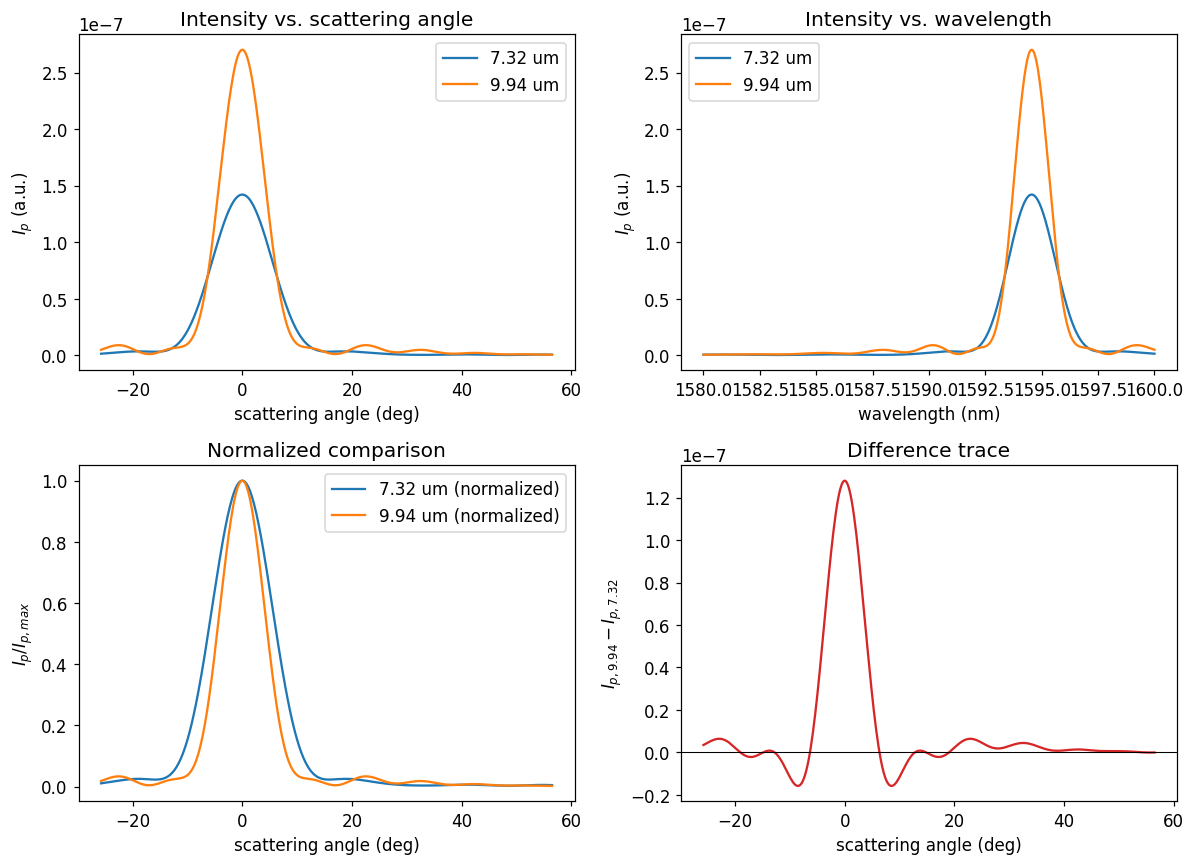

In [4]:

fig, axs = plt.subplots(2, 2, figsize=(11, 8))

axs[0, 0].plot(theta_small, Ip_small, label='7.32 um')
axs[0, 0].plot(theta_large, Ip_large, label='9.94 um')
axs[0, 0].set_xlabel('scattering angle (deg)'); axs[0, 0].set_ylabel('$I_p$ (a.u.)')
axs[0, 0].set_title('Intensity vs. scattering angle'); axs[0, 0].legend()

axs[0, 1].plot(lam_small * 1e9, Ip_small, label='7.32 um')
axs[0, 1].plot(lam_large * 1e9, Ip_large, label='9.94 um')
axs[0, 1].set_xlabel('wavelength (nm)'); axs[0, 1].set_ylabel('$I_p$ (a.u.)')
axs[0, 1].set_title('Intensity vs. wavelength'); axs[0, 1].legend()

axs[1, 0].plot(theta_small, Ip_small / Ip_small.max(), label='7.32 um (normalized)')
axs[1, 0].plot(theta_large, Ip_large / Ip_large.max(), label='9.94 um (normalized)')
axs[1, 0].set_xlabel('scattering angle (deg)'); axs[1, 0].set_ylabel('$I_p / I_{p,max}$')
axs[1, 0].set_title('Normalized comparison'); axs[1, 0].legend()

# both traces share the same theta grid (same SEALS grating mapping, diameter doesn't affect it)
diff = Ip_large - Ip_small
axs[1, 1].plot(theta_small, diff, color='C3')
axs[1, 1].axhline(0, color='k', lw=0.7)
axs[1, 1].set_xlabel('scattering angle (deg)'); axs[1, 1].set_ylabel('$I_{p,9.94} - I_{p,7.32}$')
axs[1, 1].set_title('Difference trace')

plt.tight_layout(); plt.show()



### STATISTICS


In [5]:

df1 = pd.DataFrame([
    {"bead": "7.32 um", **vars(feat_small)},
    {"bead": "9.94 um", **vars(feat_large)},
]).set_index("bead")
df1


,n_lobes,lobe_spacing_deg,peak_intensity,integrated_intensity,centroid_deg,variance_deg2
bead,,,,,,
7.32 um,1,NaN,1.421483e-07,0.000002,0.639516,72.911467
9.94 um,2,22.485192,2.701368e-07,0.000003,1.193827,88.525178



### INTERPRETATION

The simulation reproduces the paper's stated qualitative result: the larger (9.94 &micro;m)
bead shows more scattering lobes than the smaller (7.32 &micro;m) bead within the same
narrow angular window, consistent with the larger Mie size parameter `x = pi*d/lambda`
producing more oscillatory angular structure. The 9.94 &micro;m bead also shows higher peak
and integrated intensity and a wider angular variance — all directionally consistent with a
physically larger, more strongly-scattering particle.

### LIMITATION

- Both traces come from an **identical simulated 20 nm / ~80&deg; observation window** — this
  is the same narrow-band limitation the real SEALS instrument has (Sec. 2 of the paper:
  "42 resolvable scattering angles inside the provided 20nm bandwidth"), not a simulation
  shortcut. A wider-band instrument would show more lobes for both beads.
- The paper calls its diameters **nominal** — real polystyrene beads have manufacturer
  tolerance on diameter, not simulated here.
- Lobe counting depends on the chosen peak-prominence threshold
  (`extract_features(..., peak_prominence_frac=0.02)` by default) — a stated, inspectable
  choice, not a hidden tuning parameter, but a different threshold could shift exact counts
  (though the paper's qualitative ordering is robust across reasonable thresholds — see
  `tests/test_bead_features.py`).



## PART 2 — Size sweep

### QUESTION
Across a broader range of bead diameters (not just the paper's two), can particle diameter
be inferred from the angular scattering profile alone?



### PHYSICS

Same Mie forward model as Part 1, evaluated at a sequence of diameters with every other
optical parameter held fixed. If features like lobe count vary **monotonically** with
diameter, diameter could in principle be inferred (inverted) from a measured profile —
this is exactly the model-based approach `inverse/inverse_scattering.py` already implements
elsewhere in this repo (fitting diameter directly against the Mie forward model).



### VARIABLES

Diameters swept: 5, 6, 7.32, 8, 9.94, 11, 12 &micro;m (includes both paper values). All other
parameters fixed exactly as in Part 1.



### PREDICTION

Lobe count and integrated intensity should increase (or at least not decrease) monotonically
with diameter, since the size parameter `x = pi*d/lambda` increases monotonically with `d`
at fixed wavelength.


In [6]:

diameters_um = [5, 6, 7.32, 8, 9.94, 11, 12]
sweep_results = []
for d_um in diameters_um:
    lam, theta, Ip = compute_bead_trace(d_um * 1e-6)
    feat = extract_features(theta, Ip)
    sweep_results.append({"diameter_um": d_um, "theta_deg": theta, "I_p": Ip, **vars(feat)})

df2 = pd.DataFrame([{k: v for k, v in r.items() if k not in ("theta_deg", "I_p")} for r in sweep_results])
df2 = df2.set_index("diameter_um")
df2


,n_lobes,lobe_spacing_deg,peak_intensity,integrated_intensity,centroid_deg,variance_deg2
diameter_um,,,,,,
5.00,3,20.805851,1.088436e-08,2.014303e-07,4.830263,280.782979
6.00,1,NaN,5.091312e-08,8.824370e-07,1.195563,102.718490
7.32,1,NaN,1.421483e-07,1.949020e-06,0.639516,72.911467
8.00,3,18.028915,1.738392e-07,2.196930e-06,0.661420,79.547128
9.94,2,22.485192,2.701368e-07,2.844941e-06,1.193827,88.525178
11.00,1,NaN,5.806484e-07,5.385137e-06,0.836799,57.577242
12.00,3,12.241120,7.127312e-07,6.016126e-06,0.788105,58.943407



### GRAPH


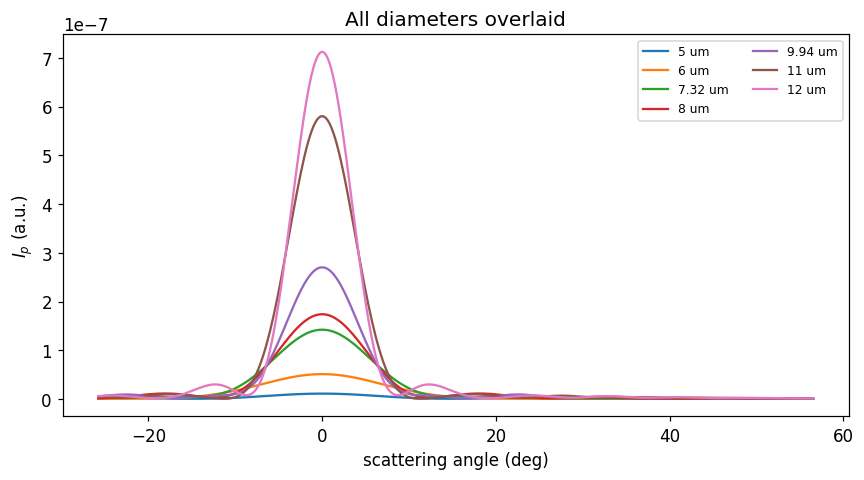

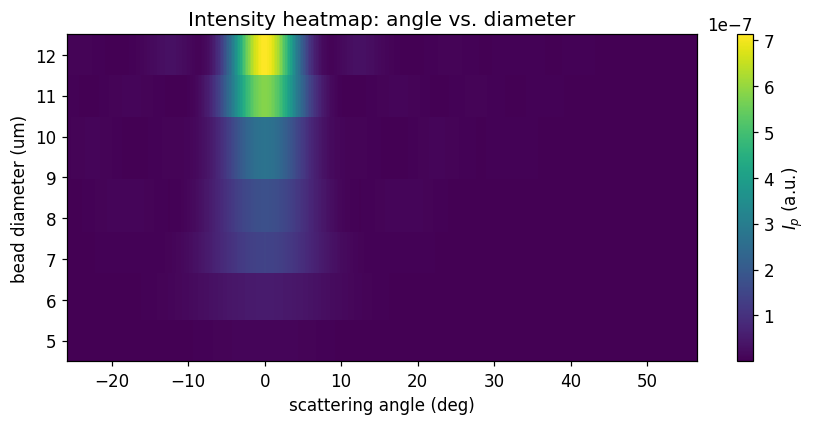

In [7]:

fig, ax = plt.subplots(figsize=(8, 4.5))
for r in sweep_results:
    ax.plot(r["theta_deg"], r["I_p"], label=f'{r["diameter_um"]} um')
ax.set_xlabel('scattering angle (deg)'); ax.set_ylabel('$I_p$ (a.u.)')
ax.set_title('All diameters overlaid'); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

# heatmap: angle x particle size (all traces share the same theta grid -> stack directly)
theta_grid = sweep_results[0]["theta_deg"]
heat = np.array([r["I_p"] for r in sweep_results])
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.pcolormesh(theta_grid, diameters_um, heat, shading='auto', cmap='viridis')
ax.set_xlabel('scattering angle (deg)'); ax.set_ylabel('bead diameter (um)')
ax.set_title('Intensity heatmap: angle vs. diameter')
plt.colorbar(im, ax=ax, label='$I_p$ (a.u.)')
plt.tight_layout(); plt.show()



### STATISTICS


In [8]:

corr = df2[["n_lobes", "peak_intensity", "integrated_intensity", "variance_deg2"]].corrwith(
    pd.Series(diameters_um, index=df2.index))
print("Pearson correlation with diameter:")
print(corr)


Pearson correlation with diameter:
n_lobes                 0.043511
peak_intensity          0.948531
integrated_intensity    0.967347
variance_deg2          -0.700483
dtype: float64



### INTERPRETATION

**The prediction above was only half right — worth stating plainly rather than smoothing
over.** `n_lobes` correlates with diameter at only **r=0.04** across the full 7-point sweep —
essentially uncorrelated, not monotonic (the raw sequence is 3, 1, 1, 3, 2, 1, 3 lobes as
diameter goes 5&rarr;12 &micro;m). Part 1's two-point comparison (7.32 vs. 9.94 &micro;m,
where lobes did increase) turns out not to generalize as a simple rule.

What **does** correlate strongly and monotonically with diameter: **peak intensity
(r=0.95)** and **integrated intensity (r=0.97)**. The physical reason for the difference:
this SEALS instrument only samples a fixed, narrow ~80&deg; angular window (Sec. 2 of the
paper), not the full Mie scattering pattern. As diameter changes, the *positions* of the
lobes shift (governed by `x=pi*d/lambda`), so how many of them happen to land inside this
particular narrow window is closer to incidental than systematic. Total scattered power,
by contrast, grows with particle cross-section regardless of exactly where the lobes land,
so it stays a robust, monotonic indicator of size.

**Practical takeaway for Part 2's research question:** for *this* instrument geometry,
diameter is better inferred from scattered **intensity magnitude** than from **lobe
counting** — the opposite of what a naive reading of Part 1's two-point example would
suggest. This is exactly the kind of instrument-specific detail a real classifier would need
to get right, and exactly why `inverse_scattering.py`'s model-based fit (which uses the full
Mie functional form, not a hand-picked feature like lobe count) is the better-conditioned
approach already recommended elsewhere in this repo (`SEALS_TO_TDGSA_REPORT.md` Sec. 5).

### LIMITATION

- Diameter is the **only** varied parameter here — real particles also vary in refractive
  index and shape, which Part 3 addresses. A classifier trained only on this sweep would
  implicitly assume refractive index and shape are already known, which is not realistic.
- 7 diameters is a coarse sweep; a real inversion (as in `inverse_scattering.py`) uses
  continuous optimization against the Mie model rather than a lookup table of discrete
  simulated points.
- All features here are **simulated / noiseless** — `SEALS_TO_TDGSA_REPORT.md` Sec. 9's
  noise-robustness findings (elsewhere in this repo) show that real measurement noise
  would degrade any feature-based inference; not modeled in this notebook.
